# 02 — Elasticity Model & Price Optimisation

Train and evaluate the conversion elasticity model, then evaluate pricing policies.

**Requires:** `make train-shipping` to have been run (loads saved model + sessions).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import average_precision_score
from sklearn.model_selection import train_test_split

sys.path.insert(0, str(Path.cwd().parent / "src"))
from shipping.elasticity import ConversionElasticityModel
from shipping.optimizer import FLAT_RATE_OPTION, SHIPPING_OPTIONS, ShippingPriceOptimizer
from shipping.synthetic import PRODUCT_MARGIN_RATE, SHIPPING_COST_TO_MERCHANT

sns.set_theme(style="whitegrid")
RESULTS = Path.cwd().parent / "results"

In [2]:
df = pd.read_parquet(RESULTS / "sessions.parquet")
model = ConversionElasticityModel.load(RESULTS / "elasticity_model.pkl")
print(f"Sessions: {len(df):,}  |  PR-AUC: {model.pr_auc_:.4f}")

Sessions: 60,000  |  PR-AUC: 0.7257


## Calibration — are predicted probabilities trustworthy?

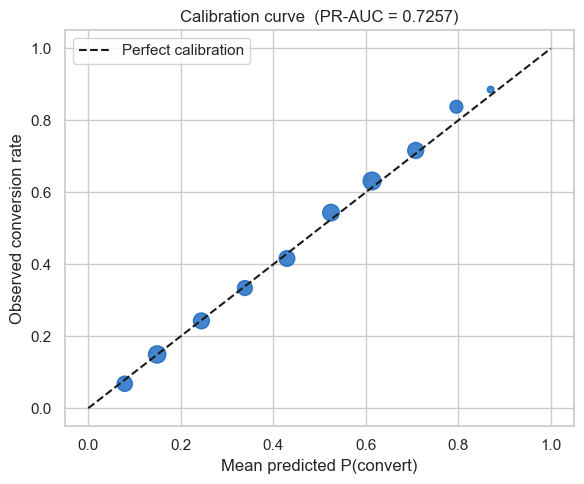

Random baseline PR-AUC: 0.4367
Model PR-AUC:           0.7257


In [3]:
_, test_df = train_test_split(df, test_size=0.20, random_state=42)
p_pred = model.predict_proba(test_df)
y_true = test_df["converted"].astype(int).values

# Calibration: bucket predictions and compare to observed rate
buckets = pd.cut(p_pred, bins=10)
cal_df = pd.DataFrame({"predicted": p_pred, "actual": y_true, "bucket": buckets})
cal_stats = (
    cal_df.groupby("bucket", observed=True)
    .agg(mean_pred=("predicted", "mean"), mean_actual=("actual", "mean"), n=("actual", "size"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(
    cal_stats["mean_pred"],
    cal_stats["mean_actual"],
    s=cal_stats["n"] / 10,
    alpha=0.8,
    color="#1565C0",
)
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.set_xlabel("Mean predicted P(convert)")
ax.set_ylabel("Observed conversion rate")
ax.set_title(f"Calibration curve  (PR-AUC = {model.pr_auc_:.4f})")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Random baseline PR-AUC: {y_true.mean():.4f}")
print(f"Model PR-AUC:           {model.pr_auc_:.4f}")

## Price elasticity curves — counterfactual predictions by segment

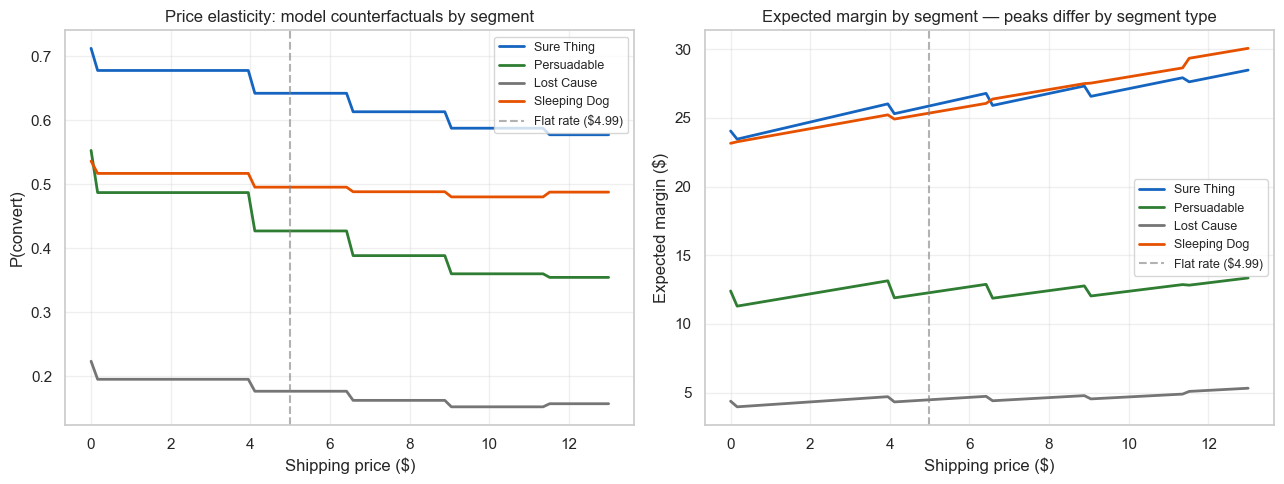

In [4]:
prices = np.linspace(0, 13, 80)
seg_colors = {
    "sure_thing": "#1565C0",
    "persuadable": "#2E7D32",
    "lost_cause": "#757575",
    "sleeping_dog": "#E65100",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for seg in ["sure_thing", "persuadable", "lost_cause", "sleeping_dog"]:
    seg_sample = test_df[test_df["segment"] == seg].head(300)
    label = seg.replace("_", " ").title()
    color = seg_colors[seg]

    p_curve = [model.predict_at_price(seg_sample, p).mean() for p in prices]
    em_curve = [
        (
            model.predict_at_price(seg_sample, p)
            * (seg_sample["cart_value"] * PRODUCT_MARGIN_RATE + p - SHIPPING_COST_TO_MERCHANT)
        ).mean()
        for p in prices
    ]

    axes[0].plot(prices, p_curve, label=label, color=color, linewidth=2)
    axes[1].plot(prices, em_curve, label=label, color=color, linewidth=2)

for ax in axes:
    ax.axvline(
        FLAT_RATE_OPTION.price,
        color="grey",
        linestyle="--",
        alpha=0.6,
        label=f"Flat rate (${FLAT_RATE_OPTION.price:.2f})",
    )
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

axes[0].set(
    xlabel="Shipping price ($)",
    ylabel="P(convert)",
    title="Price elasticity: model counterfactuals by segment",
)
axes[1].set(
    xlabel="Shipping price ($)",
    ylabel="Expected margin ($)",
    title="Expected margin by segment — peaks differ by segment type",
)

plt.tight_layout()
plt.show()

## Policy comparison

In [5]:
optimizer = ShippingPriceOptimizer(model)
policy_df = optimizer.compare_policies(test_df)
print(policy_df.to_string(index=False))

flat_row = policy_df[policy_df["policy"].str.startswith("Flat")].iloc[0]
opt_row = policy_df[policy_df["policy"].str.startswith("Opt")].iloc[0]

print(
    f"\nMargin improvement: +{(opt_row.mean_expected_margin - flat_row.mean_expected_margin) / abs(flat_row.mean_expected_margin):.1%}"
)
print(f"Conversion delta:   {(opt_row.mean_p_convert - flat_row.mean_p_convert) * 100:+.1f} pp")

                         policy  mean_expected_margin  mean_p_convert  margin_per_converted
              Flat rate ($4.99)               16.5550          0.4310               38.4099
           Always free shipping               15.6409          0.5049               30.9805
        Always Express ($12.99)               18.7477          0.3870               48.4414
Optimised (max expected margin)               19.2708          0.4443               43.3761

Margin improvement: +16.4%
Conversion delta:   +1.3 pp


## Segment price distribution under the optimised policy

In [6]:
seg_price = optimizer.segment_price_distribution(test_df)
print("Fraction of sessions receiving each option, by segment:")
print(seg_price.round(3).to_string())

Fraction of sessions receiving each option, by segment:
recommended_label  Expedited  Express  Free Shipping  Standard
segment                                                       
lost_cause             0.041    0.748          0.180     0.031
persuadable            0.043    0.557          0.364     0.036
sleeping_dog           0.021    0.805          0.144     0.030
sure_thing             0.061    0.775          0.127     0.037
